$\phi_0 = \dfrac{h}{2e}$: quantum de fluxo magnético

In [1]:
from scipy import constants

phi0=constants.h/(2*constants.e)
phi0 #Wb = T/m²''

2.0678338484619295e-15

$\phi=BS$: fluxo sobre a célula unitária primitiva

$\phi/\phi_0 = 1/q$, q = 1,2,3 ... 

nova célula unitária: $\tilde{\mathbf{L}}_1 = q\mathbf{L}_1 \implies \tilde{\phi}/\phi_0 = 1$

eixo y paralelo a $\mathbf{L}_2$

gauge: $\mathbf{A}=Bx\hat y$

fase: $\phi_{ij} = \dfrac{2\pi}{\phi_0} \int_{\mathbf{R}_i}^{\mathbf{R}_j} \mathbf{A}\cdot\text{d}\mathbf{r} = \dfrac{2\pi}{\phi_0} \dfrac{B}{2} (R_{jx} + R_{ix}) (R_{jy}-R_{iy})$

In [2]:
%run twisted_graphene.py

In [84]:
g=TwistedBilayerGraphene(1,0)

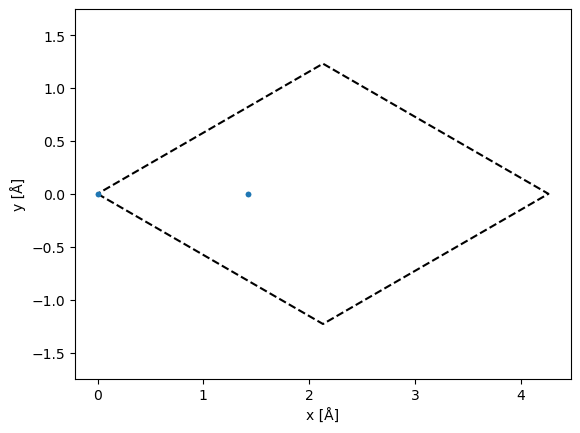

In [53]:
L1,L2=g.L1,g.L2
r=g.r
N=g.N
vertices=np.array([[0,0,0],L1,L1+L2,L2,[0,0,0]])
plt.plot(vertices[:,0],vertices[:,1],'k--')
plt.plot(r[:,0],r[:,1],'.',color='tab:blue')
plt.axis('equal')
plt.xlabel('x [Å]')
plt.ylabel('y [Å]')
plt.show()

In [85]:
g.generate_magnetic_unit_cell(100) #irreversible

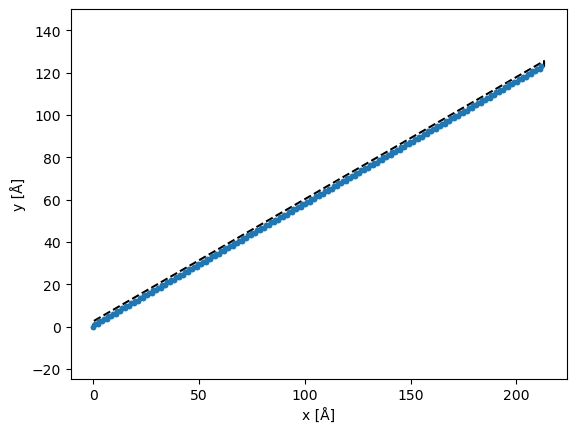

In [86]:
L1,L2=g.L1,g.L2
r=g.r
N=g.N
vertices=np.array([[0,0,0],L1,L1+L2,L2,[0,0,0]])
plt.plot(vertices[:,0],vertices[:,1],'k--')
plt.plot(r[:,0],r[:,1],'.',color='tab:blue')
plt.axis('equal')
plt.xlabel('x [Å]')
plt.ylabel('y [Å]')
plt.show()

In [87]:
0.6*2.46

1.476

In [88]:
g.calc_hops(1.5)

In [89]:
g.include_peierls_substitution()

In [90]:
# point=g.Kp[0]+(1/3)*(g.Kp[1]-g.Kp[0])
# g.set_kpath([point,point],[1])

g.set_kpath([g.Kp[0],g.Kp[1]],[100])

In [91]:
g.set_hamiltonian(0.0,0.0)

In [92]:
g.calc_bands(min(50,4*g.N-2),0.0)

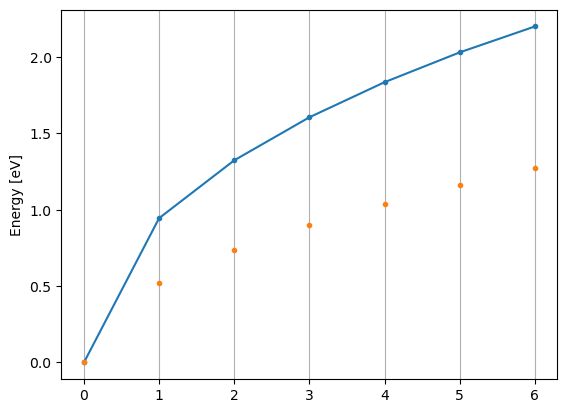

In [104]:
# plt.plot(g.ell,g.bands,'b.')
# plt.xticks(g.ell[g.kticks],["K'",'$\Gamma$'])

n=np.arange(g.bands[0][25::4].size)
plt.plot(n,g.bands[0][25::4],'.-')
plt.plot(n,wc*np.sqrt(n),'.')

plt.grid(True,axis='x')
plt.ylabel('Energy [eV]')
plt.show()

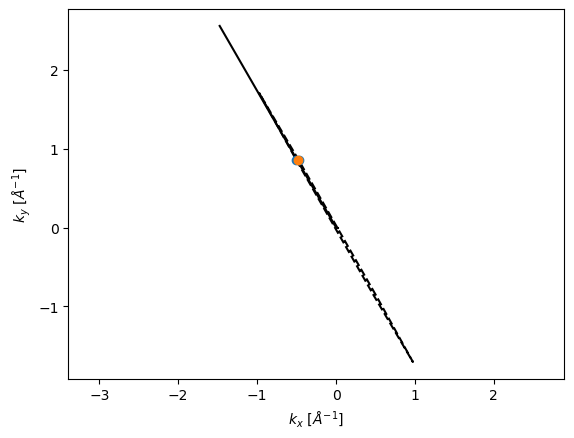

In [97]:
# _kpoints=[g.K[0],g.Gamma,g.M[1],g.K[1],g.Gamma]
_kpoints=[g.Kp[0],g.Kp[1]]
_kpoints=np.array(_kpoints)

vertices=np.array([g.K[0],g.Kp[0],g.K[1],g.Kp[1],g.K[2],g.Kp[2],g.K[0]])
plt.plot([0,g.G1[0]],[0,g.G1[1]],'k-')
plt.plot([0,g.G2[0]],[0,g.G2[1]],'k-')
plt.plot(vertices[:,0],vertices[:,1],'k--')
plt.plot(_kpoints[:,0],_kpoints[:,1],'o-',lw=2)

point=g.Kp[0]+(1/3)*(g.Kp[1]-g.Kp[0])
plt.plot([point[0]],[point[1]],'o')

plt.axis('equal')
plt.xlabel(r'$k_x$ [$Å^{-1}$]')
plt.ylabel(r'$k_y$ [$Å^{-1}$]')
plt.show()

In [94]:
g.B*1e20 #T

394.5615800941619

comprimento magnético:

In [95]:
lB=np.sqrt(constants.hbar/(constants.e*g.B)) #Angstrom
lB

12.915924170446566

$l_B>>a$

In [96]:
lB/2.46 #>>1

5.250375679043319

In [103]:
a=2.46
t=2.8922
vf=2*t*a/3
wc=np.sqrt(2)*vf/lB
wc

0.5193518477063527